# Brain Tumor Prediction Using EDA, ML, Dl

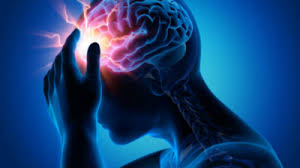

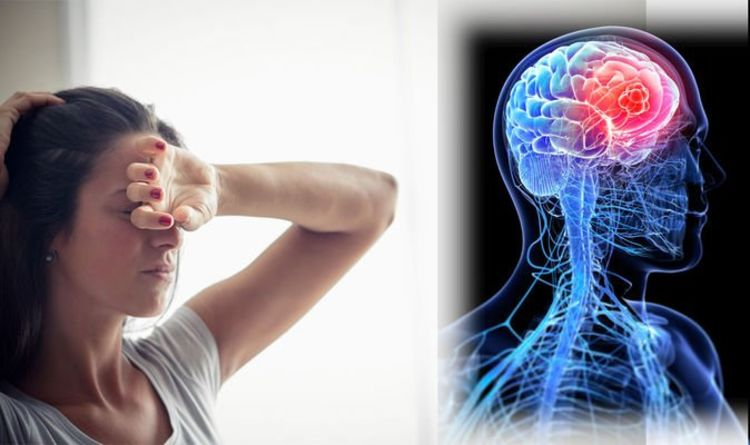

# Project Objective
The primary objective of this project is to develop an accurate and reliable machine learning-based system for predicting the presence of brain tumors using patient clinical data and diagnostic features such as MRI findings. Early and precise detection of brain tumors is critical for effective treatment planning and improving patient outcomes.

This project aims to:

* **Collect and preprocess** relevant clinical and diagnostic data including demographic, lifestyle, and medical history information.
* **Encode and scale** the input features to ensure compatibility with machine learning models.
* **Train and optimize** predictive models, including traditional machine learning classifiers and deep learning models, to distinguish between benign and malignant brain tumors or detect tumor presence.
* **Deploy an interactive application** that allows healthcare professionals to input patient data and receive real-time predictions with confidence scores.
* **Facilitate early diagnosis** and decision-making support by providing accurate, interpretable predictions to assist clinicians in identifying patients who require further medical investigation or treatment.

Ultimately, the project strives to leverage machine learning to enhance diagnostic accuracy, reduce the time to diagnosis, and improve the overall management of brain tumor patients.


# Step 1: Import Required Modules

In [187]:
# For EDA
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython.core.pylabtools")

# For Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.svm import SVC
from keras.models import Sequential
from keras.layers import Dense
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.exceptions import FitFailedWarning

# For Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Step 2: Loading Data 

In [188]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ankushpanday1/brain-tumor-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pankh\.cache\kagglehub\datasets\ankushpanday1\brain-tumor-prediction-dataset\versions\1


In [189]:
all_files=os.listdir(path)#directory ko list form main batana
all_files

['Brain_Tumor_Prediction_Dataset.csv']

In [190]:
file_path=path+'\\'+all_files[0]
file_path

'C:\\Users\\pankh\\.cache\\kagglehub\\datasets\\ankushpanday1\\brain-tumor-prediction-dataset\\versions\\1\\Brain_Tumor_Prediction_Dataset.csv'

In [191]:
df=pd.read_csv(file_path)
print('file loaded successfully')

file loaded successfully


# Step 3: Understanding Data using EDA

In [192]:
df.head()

,Age,Gender,Country,Tumor_Size,Tumor_Location,MRI_Findings,Genetic_Risk,Smoking_History,Alcohol_Consumption,Radiation_Exposure,...,Chronic_Illness,Blood_Pressure,Diabetes,Tumor_Type,Treatment_Received,Survival_Rate(%),Tumor_Growth_Rate,Family_History,Symptom_Severity,Brain_Tumor_Present
0,66,Other,China,8.70,Cerebellum,Severe,81,No,Yes,Medium,...,Yes,122/88,No,Malignant,NaN,58,Slow,Yes,Mild,No
1,87,Female,Australia,8.14,Temporal,Normal,65,No,Yes,Medium,...,No,126/119,No,Malignant,NaN,13,Rapid,Yes,Severe,No
2,41,Male,Canada,6.02,Occipital,Severe,100,Yes,No,Low,...,No,118/65,No,Benign,Chemotherapy,67,Slow,Yes,Moderate,Yes
3,52,Male,Japan,7.26,Occipital,Normal,19,Yes,Yes,High,...,No,165/119,Yes,Benign,Radiation,85,Moderate,No,Moderate,Yes
4,84,Female,Brazil,7.94,Temporal,Abnormal,47,No,Yes,Medium,...,Yes,156/97,Yes,Malignant,NaN,17,Moderate,No,Moderate,No


In [193]:
df.tail()

,Age,Gender,Country,Tumor_Size,Tumor_Location,MRI_Findings,Genetic_Risk,Smoking_History,Alcohol_Consumption,Radiation_Exposure,...,Chronic_Illness,Blood_Pressure,Diabetes,Tumor_Type,Treatment_Received,Survival_Rate(%),Tumor_Growth_Rate,Family_History,Symptom_Severity,Brain_Tumor_Present
249995,77,Female,Germany,2.05,Frontal,Normal,9,Yes,Yes,High,...,No,93/80,Yes,Benign,Chemotherapy,36,Rapid,Yes,Mild,No
249996,89,Other,Japan,3.55,Parietal,Normal,75,Yes,No,Low,...,Yes,119/112,Yes,Benign,Radiation,80,Slow,Yes,Moderate,Yes
249997,16,Other,Russia,8.54,Temporal,Normal,52,No,Yes,Low,...,Yes,101/68,Yes,Malignant,Radiation,72,Slow,No,Severe,Yes
249998,56,Other,Germany,2.17,Cerebellum,Severe,95,Yes,No,High,...,No,179/106,Yes,Benign,NaN,83,Rapid,Yes,Moderate,Yes
249999,54,Female,Australia,5.19,Parietal,Abnormal,83,Yes,No,Medium,...,No,147/82,Yes,Malignant,Radiation,94,Slow,No,Mild,No


In [194]:
df.shape

(250000, 21)

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Age                  250000 non-null  int64  
 1   Gender               250000 non-null  object 
 2   Country              250000 non-null  object 
 3   Tumor_Size           250000 non-null  float64
 4   Tumor_Location       250000 non-null  object 
 5   MRI_Findings         250000 non-null  object 
 6   Genetic_Risk         250000 non-null  int64  
 7   Smoking_History      250000 non-null  object 
 8   Alcohol_Consumption  250000 non-null  object 
 9   Radiation_Exposure   250000 non-null  object 
 10  Head_Injury_History  250000 non-null  object 
 11  Chronic_Illness      250000 non-null  object 
 12  Blood_Pressure       250000 non-null  object 
 13  Diabetes             250000 non-null  object 
 14  Tumor_Type           250000 non-null  object 
 15  Treatment_Receive

In [196]:
df.describe()

,Age,Tumor_Size,Genetic_Risk,Survival_Rate(%)
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,46.962424,5.251768,49.998916,54.481532
std,24.517143,2.742576,29.178031,25.999932
min,5.000000,0.500000,0.000000,10.000000
25%,26.000000,2.870000,25.000000,32.000000
50%,47.000000,5.260000,50.000000,55.000000
75%,68.000000,7.630000,75.000000,77.000000
max,89.000000,10.000000,100.000000,99.000000


In [197]:
df.describe(include='object').T

,count,unique,top,freq
Gender,250000,3,Male,83407
Country,250000,12,Brazil,20985
Tumor_Location,250000,5,Parietal,50187
MRI_Findings,250000,3,Abnormal,83737
Smoking_History,250000,2,Yes,125150
Alcohol_Consumption,250000,2,Yes,125173
Radiation_Exposure,250000,3,Low,83513
Head_Injury_History,250000,2,Yes,125029
Chronic_Illness,250000,2,Yes,125321
Blood_Pressure,250000,5551,146/117,70


In [198]:
df['Blood_Pressure'].unique()

array(['122/88', '126/119', '118/65', ..., '180/63', '105/80', '155/69'],
      dtype=object)

In [199]:
df[['High_BP', 'Low_BP']] = df['Blood_Pressure'].str.split('/', expand=True).astype(int)
df.drop('Blood_Pressure', axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Age                  250000 non-null  int64  
 1   Gender               250000 non-null  object 
 2   Country              250000 non-null  object 
 3   Tumor_Size           250000 non-null  float64
 4   Tumor_Location       250000 non-null  object 
 5   MRI_Findings         250000 non-null  object 
 6   Genetic_Risk         250000 non-null  int64  
 7   Smoking_History      250000 non-null  object 
 8   Alcohol_Consumption  250000 non-null  object 
 9   Radiation_Exposure   250000 non-null  object 
 10  Head_Injury_History  250000 non-null  object 
 11  Chronic_Illness      250000 non-null  object 
 12  Diabetes             250000 non-null  object 
 13  Tumor_Type           250000 non-null  object 
 14  Treatment_Received   187252 non-null  object 
 15  Survival_Rate(%) 

In [200]:
df.isna().mean() * 100

Age                     0.0000
Gender                  0.0000
Country                 0.0000
Tumor_Size              0.0000
Tumor_Location          0.0000
MRI_Findings            0.0000
Genetic_Risk            0.0000
Smoking_History         0.0000
Alcohol_Consumption     0.0000
Radiation_Exposure      0.0000
Head_Injury_History     0.0000
Chronic_Illness         0.0000
Diabetes                0.0000
Tumor_Type              0.0000
Treatment_Received     25.0992
Survival_Rate(%)        0.0000
Tumor_Growth_Rate       0.0000
Family_History          0.0000
Symptom_Severity        0.0000
Brain_Tumor_Present     0.0000
High_BP                 0.0000
Low_BP                  0.0000
dtype: float64

In [201]:
df.duplicated().mean()

np.float64(0.0)

In [202]:
df['Treatment_Received'].unique()

array([nan, 'Chemotherapy', 'Radiation', 'Surgery'], dtype=object)

In [203]:
df['Treatment_Received'] = df['Treatment_Received'].fillna('No')
df['Treatment_Received'].unique()

array(['No', 'Chemotherapy', 'Radiation', 'Surgery'], dtype=object)

In [204]:
df.isna().mean() * 100

Age                    0.0
Gender                 0.0
Country                0.0
Tumor_Size             0.0
Tumor_Location         0.0
MRI_Findings           0.0
Genetic_Risk           0.0
Smoking_History        0.0
Alcohol_Consumption    0.0
Radiation_Exposure     0.0
Head_Injury_History    0.0
Chronic_Illness        0.0
Diabetes               0.0
Tumor_Type             0.0
Treatment_Received     0.0
Survival_Rate(%)       0.0
Tumor_Growth_Rate      0.0
Family_History         0.0
Symptom_Severity       0.0
Brain_Tumor_Present    0.0
High_BP                0.0
Low_BP                 0.0
dtype: float64

In [205]:
def outlier_check(row, colname):  
    Q1 = row[colname].quantile(0.25)
    Q3 = row[colname].quantile(0.75)
    IQR = Q3 - Q1
    lower_b = Q1 - 1.5 * IQR
    upper_b = Q3 + 1.5 * IQR
    outlier = row.loc[(row[colname] < lower_b) | (row[colname] > upper_b)]
    return outlier   
outliers = pd.DataFrame() 

In [206]:
for col in df.select_dtypes(include=['number']).columns: 
    outliers_in_col = outlier_check(df, col) 
    outliers = pd.concat([outliers, outliers_in_col])
outliers.reset_index(drop=True, inplace=True)
total_rows = len(df)
outlier_count = len(outliers)
outlier_ratio = (outlier_count / total_rows) * 100
if outliers.empty:
    print("No outliers")
else:
    print(f"Number of Outliers: {outlier_count}")
    print(f"Outlier Ratio: {outlier_ratio:.2f}%")

No outliers


# Data Visualisation

### 1. Histogram of Numerical Features

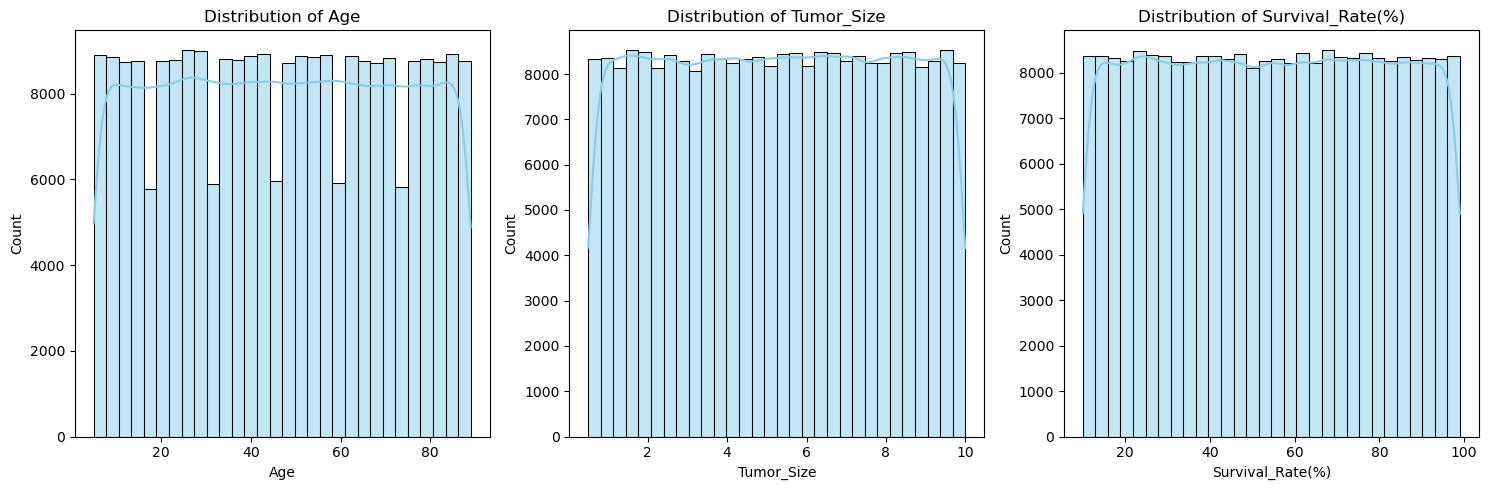

In [207]:
numerical_cols = ['Age', 'Tumor_Size', 'Survival_Rate(%)']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=30, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### 2. Count Plot for Categorical Features

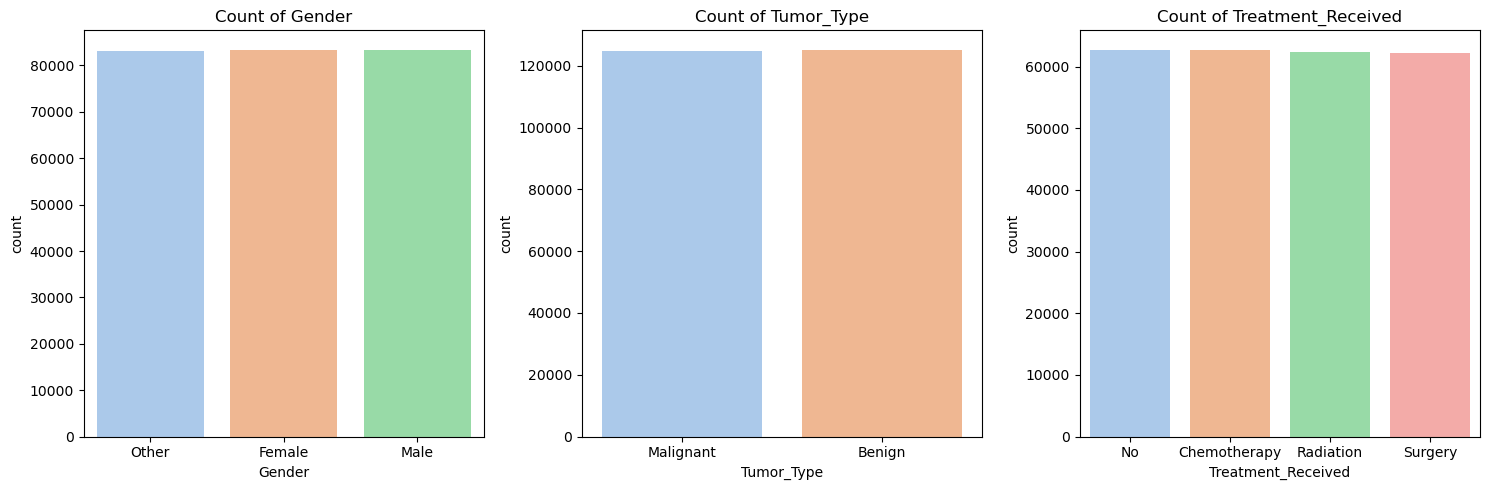

In [208]:
### 2. Count Plot for Categorical Features ###
categorical_cols = ['Gender', 'Tumor_Type', 'Treatment_Received']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col, hue=col,palette="pastel")
    plt.title(f"Count of {col}")
plt.tight_layout()
plt.show()


### 3. Box Plot: Tumor Size by Tumor Type

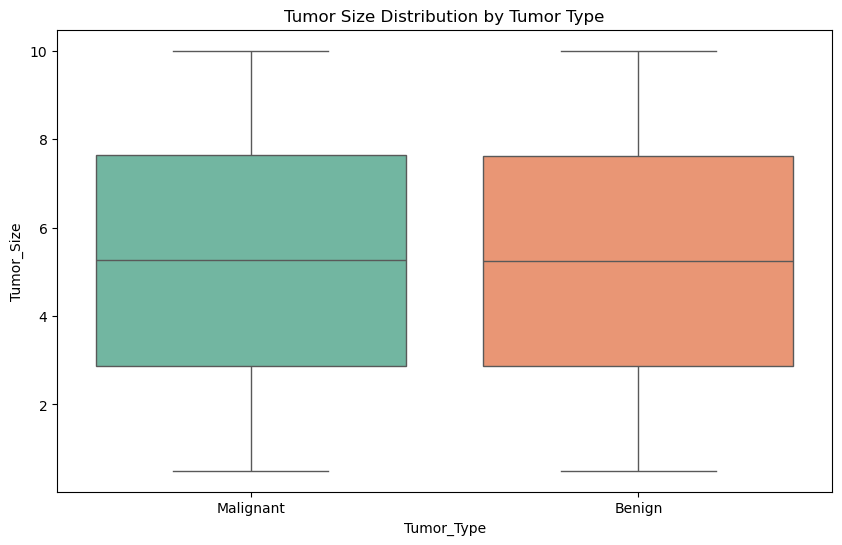

In [209]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tumor_Type', y='Tumor_Size',hue='Tumor_Type', palette="Set2")
plt.title("Tumor Size Distribution by Tumor Type")
plt.xticks(rotation=0)
plt.show()

### 4. Scatter Plot: Tumor Size vs Survival Rate

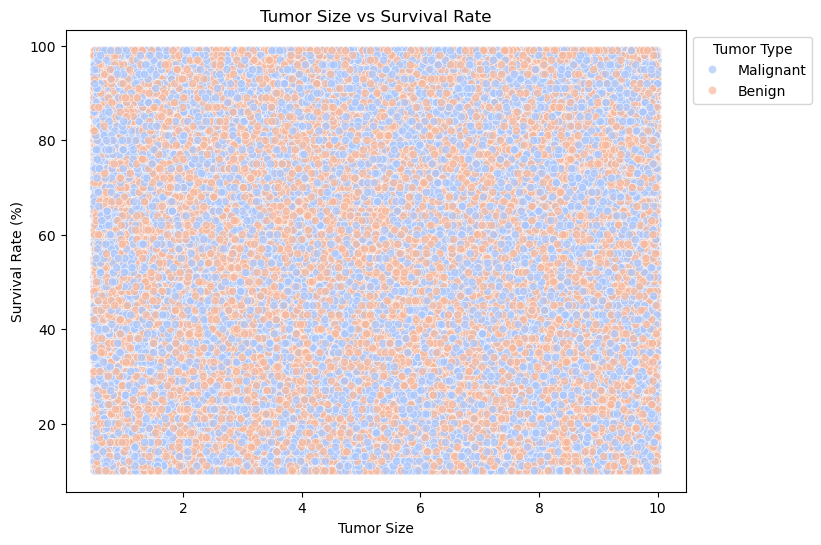

In [210]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Tumor_Size', y='Survival_Rate(%)', hue='Tumor_Type', palette='coolwarm', alpha=0.7)
plt.title("Tumor Size vs Survival Rate")
plt.xlabel("Tumor Size")
plt.ylabel("Survival Rate (%)")
plt.legend(title="Tumor Type", bbox_to_anchor=(1, 1))
plt.show()


### 5. Bar Plot: Smoking History vs Tumor Typ

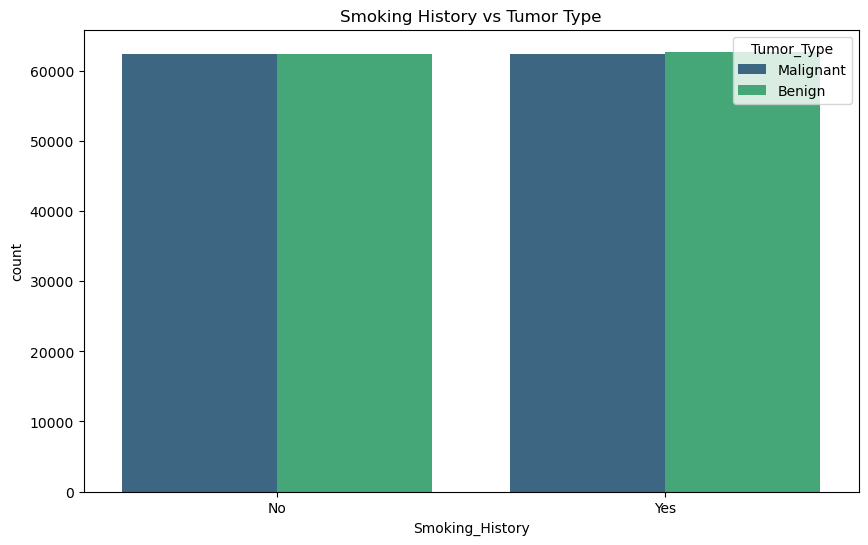

In [211]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Smoking_History', hue='Tumor_Type', palette='viridis')
plt.title("Smoking History vs Tumor Type")
plt.xticks(rotation=0)
plt.show()

### 6. Violin Plot: Tumor Growth Rate vs Tumor Size 

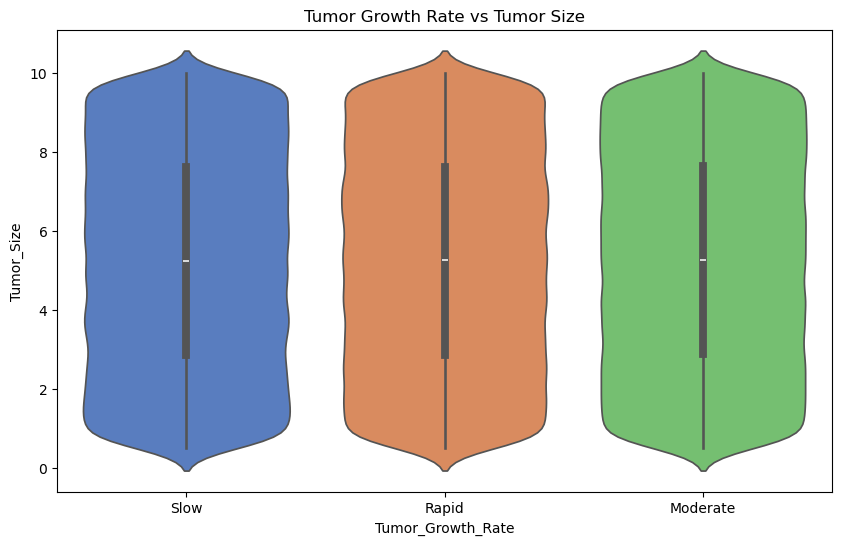

In [212]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Tumor_Growth_Rate', y='Tumor_Size', hue='Tumor_Growth_Rate',palette="muted")
plt.title("Tumor Growth Rate vs Tumor Size")
plt.xticks(rotation=0)
plt.show()


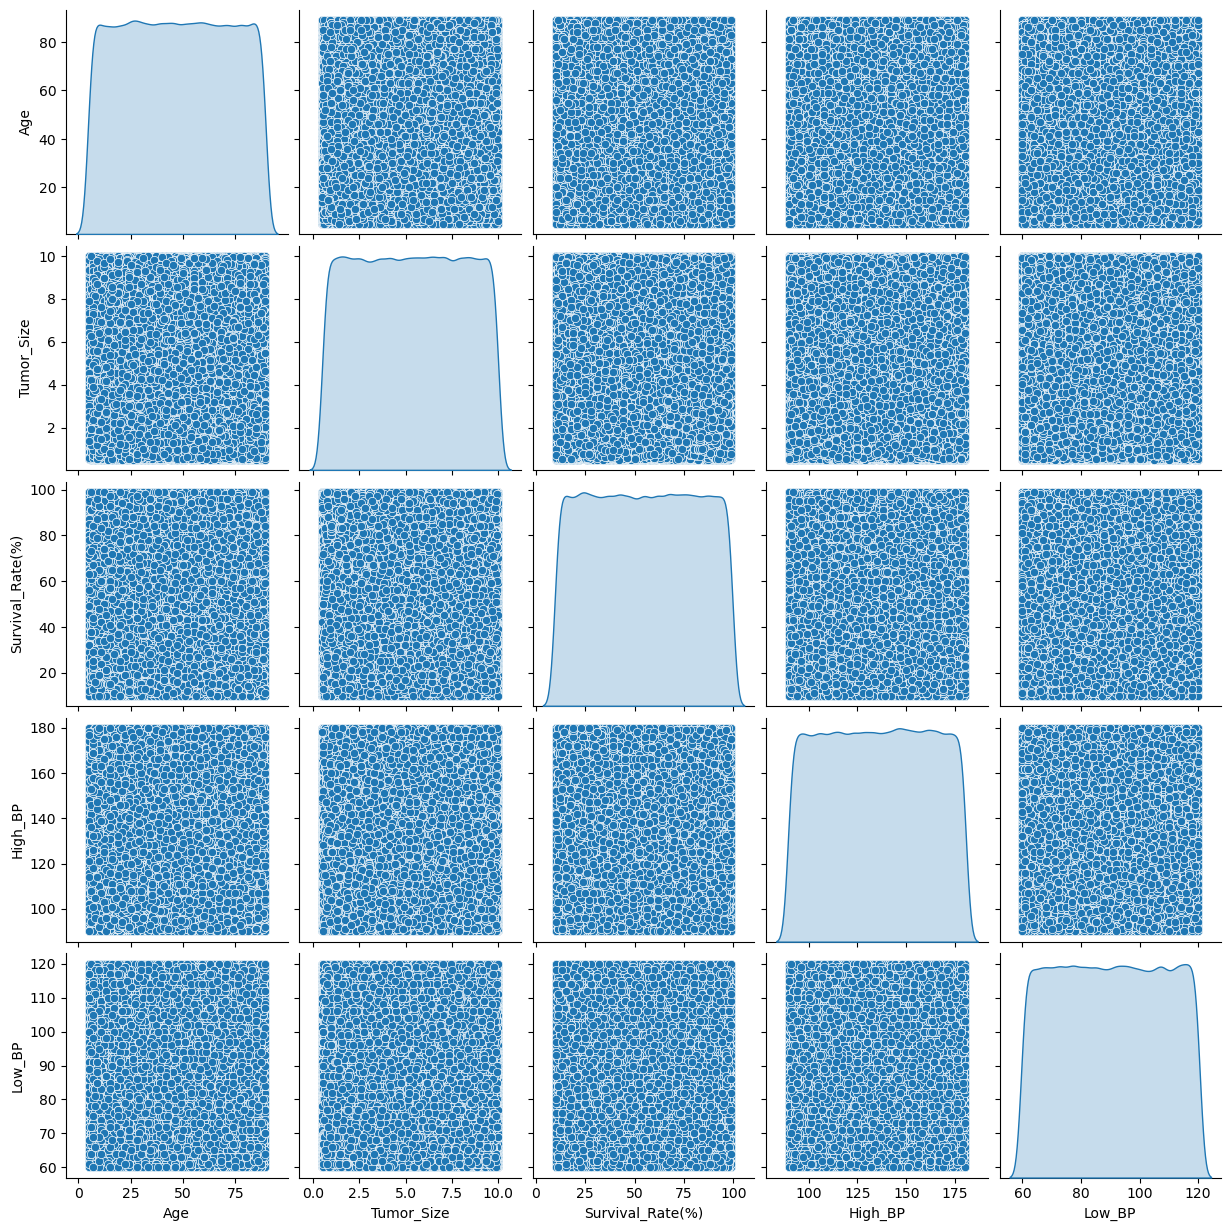

In [213]:
sns.pairplot(df[['Age', 'Tumor_Size', 'Survival_Rate(%)', 'High_BP', 'Low_BP']], diag_kind="kde")
plt.show()

In [214]:
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:  
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

original_object_cols = list(label_encoders.keys()) 
num_columns = df.select_dtypes(include=['int64', 'float64']).columns

num_columns_to_scale = [col for col in num_columns if col not in original_object_cols and col != 'Brain_Tumor_Present']

scaler = StandardScaler()
df[num_columns_to_scale] = scaler.fit_transform(df[num_columns_to_scale])

print("Scaled Numerical Data:")
df[num_columns_to_scale].head()


Scaled Numerical Data:


,Age,Tumor_Size,Genetic_Risk,Survival_Rate(%),High_BP,Low_BP
0,0.776502,1.257299,1.062482,0.135326,-0.498807,-0.115998
1,1.633047,1.053111,0.514124,-1.595451,-0.346283,1.644008
2,-0.243195,0.280114,1.713659,0.481482,-0.651331,-1.421808
3,0.205472,0.732244,-1.062408,1.173793,1.140824,1.644008
4,1.510684,0.980187,-0.102780,-1.441604,0.797646,0.394972


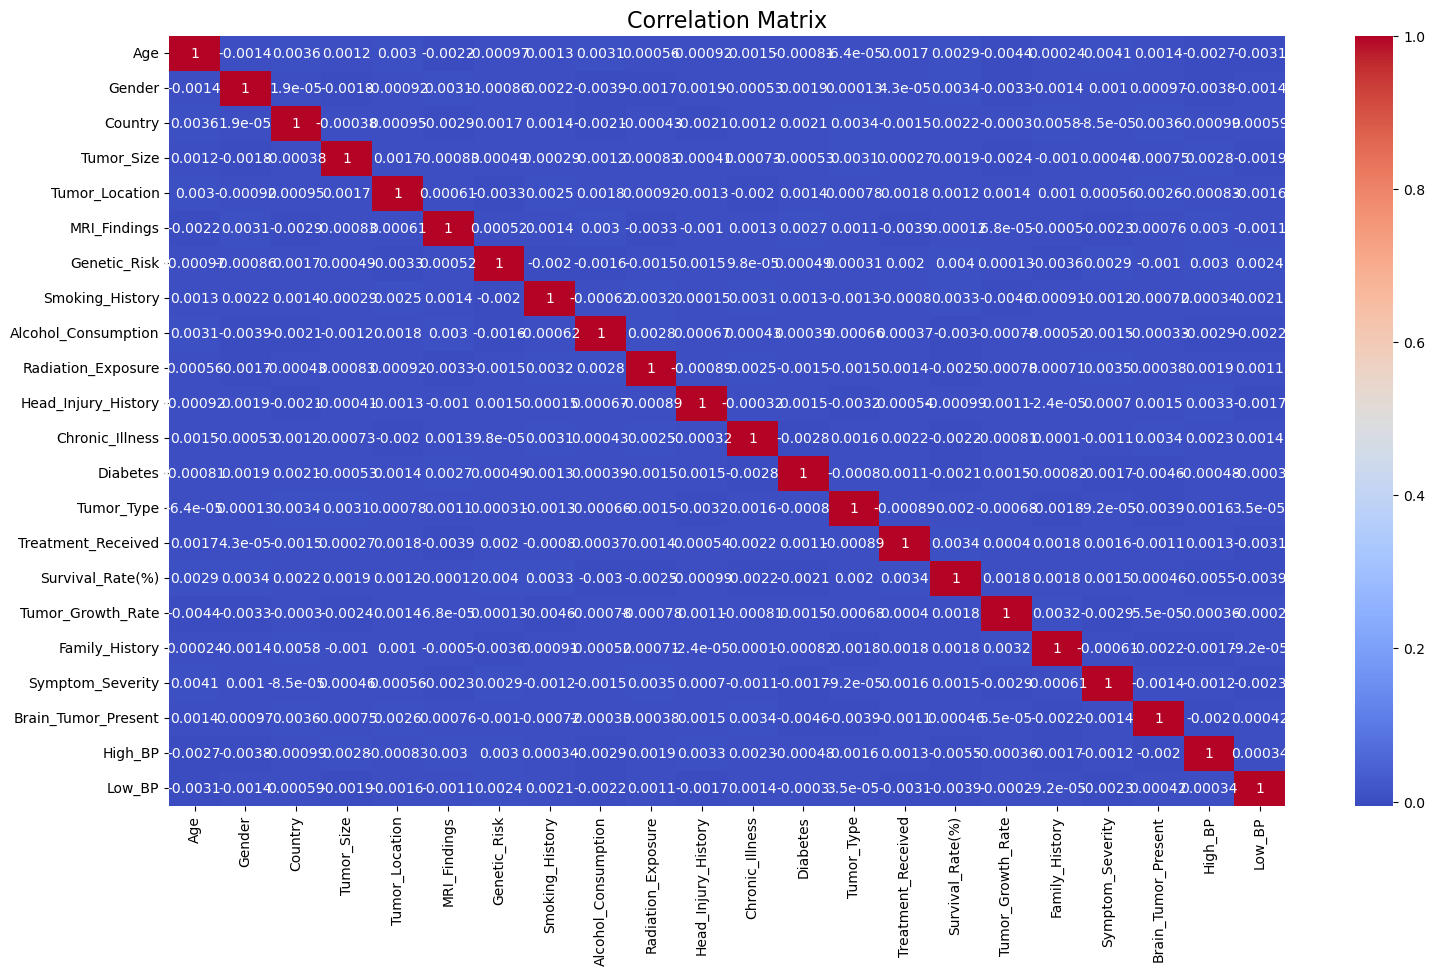

In [215]:
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

correlation_matrix = df.corr(method='pearson')

plt.figure(figsize=(18, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()


# Step 4: Divide Data into Train and Test

In [216]:
X = df.drop('Brain_Tumor_Present', axis=1)
y = df['Brain_Tumor_Present'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Step 5 ML Model Building

### Step 5.1: Logistic Regression 

###### Step 5.1.1 Import Logistic Regression 

In [217]:
model_lr=LogisticRegression()#Model Object
model_lr.fit(X_train,y_train)#Training/Model Building:#Learn pattern in this step

LogisticRegression()

###### Step 5.1.2: Model Prediction

In [218]:
y_pred=model_lr.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 1])

###### Step 5.1.3:  Confusion Matrix to Evaluate Classification

In [219]:
cm=confusion_matrix(y_test,y_pred)

In [220]:
print(cm)

[[13310 11719]
 [13229 11742]]


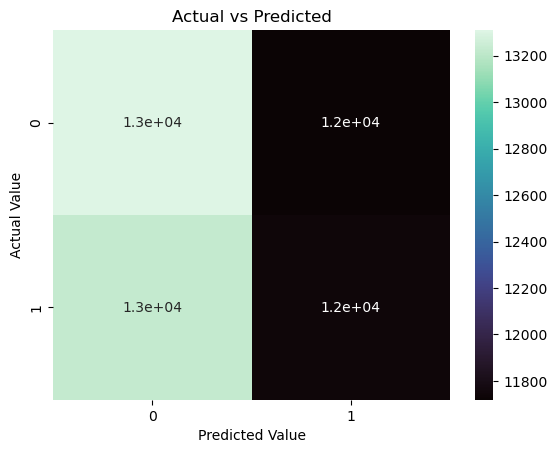

In [221]:
plt.title('Actual vs Predicted')
sns.heatmap(cm,annot = True,cmap='mako')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

In [222]:
cm

array([[13310, 11719],
       [13229, 11742]])

In [223]:
cm.ravel()

array([13310, 11719, 13229, 11742])

In [224]:
TN,FP,FN,TP=cm.ravel()

In [225]:
ps=precision_score(y_test,y_pred)
print('Precision Score:', ps)

Precision Score: 0.5004901751843485


In [226]:
acs=accuracy_score(y_test,y_pred)
print('Accuracy score:',acs)

Accuracy score: 0.50104


In [227]:
rs=recall_score(y_test,y_pred)
print('Recall Score is :',rs)

Recall Score is : 0.47022546153538103


In [228]:
f1_sc=f1_score(y_test,y_pred)
print('F1 score:',f1_sc)

F1 score: 0.4848860257680872


In [229]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.50      0.53      0.52     25029
           1       0.50      0.47      0.48     24971

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000



###### Step 5.1.4: Checking Model Score

In [230]:
#Model Score same as Accuray Score
lr_score=model_lr.score(X_test,y_test)
lr_score

0.50104

### Step 5.2: Naive Bayes ML Model

###### Step 5.2.1: Import Naive Bayes

In [231]:
model_nv = GaussianNB()
model_nv.fit(X_train,y_train) 

GaussianNB()

###### Step 5.2.2: Model Prediction

In [232]:
y_pred=model_nv.predict(X_test)

In [233]:
print('Accuracy Score:',accuracy_score(y_test,y_pred))
print('Precision Score:',precision_score(y_test,y_pred))
print('Recall Score:',recall_score(y_test,y_pred))
print('F1 Score:',f1_score(y_test,y_pred))

Accuracy Score: 0.49944
Precision Score: 0.49874972581706517
Recall Score: 0.4552881342357134
F1 Score: 0.47602897458443244


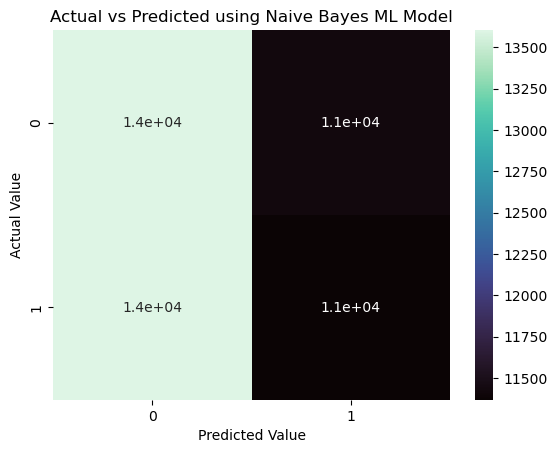

In [234]:
cm=confusion_matrix(y_test,y_pred)
plt.title('Actual vs Predicted using Naive Bayes ML Model')
sns.heatmap(cm,annot = True,cmap='mako')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

In [235]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.50      0.54      0.52     25029
           1       0.50      0.46      0.48     24971

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000



###### Step 5.2.3: Checking Model Score 

In [236]:
nv_score=model_nv.score(X_test,y_test)
print('Naive Bayes Score:',nv_score)

Naive Bayes Score: 0.49944


In [237]:
#model_svc=SVC()
#model_svc.fit(X_train,y_train)

In [238]:
#y_pred=model_svc.predict(X_test)

In [239]:
#print('Accuracy Score:',accuracy_score(y_test,y_pred))
#print('Precision Score:',precision_score(y_test,y_pred))
#print('Recall Score:',recall_score(y_test,y_pred))
#print('F1 Score:',f1_score(y_test,y_pred))

In [240]:
#print(classification_report(y_test,y_pred))

In [241]:
#cm=confusion_matrix(y_test,y_pred)
#plt.title('Actual vs Predicted using SVC ML Model')
#sns.heatmap(cm,annot = True,cmap='mako')
#plt.xlabel('Predicted Value')
#plt.ylabel('Actual Value')
#plt.show()

In [242]:
#svm_score=accuracy_score(y_test,y_pred)

In [243]:
#lr_score,nv_score,svm_score

In [244]:
#model_svc.score(X_test,y_test)

### Step 5.3: Decision Tree Model 

###### Step 5.3.1: Import Decision Tree Model

In [245]:
model_dt=DecisionTreeClassifier()
model_dt.fit(X_train,y_train)

DecisionTreeClassifier()

###### Step 5.3.2: Model Prediction

In [246]:
y_pred= model_dt.predict(X_test)

In [247]:
print('Accuracy Score:',accuracy_score(y_test,y_pred))
print('Precision Score:',precision_score(y_test,y_pred))
print('Recall Score:',recall_score(y_test,y_pred))
print('F1 Score:',f1_score(y_test,y_pred))

Accuracy Score: 0.49678
Precision Score: 0.4962115169883554
Recall Score: 0.4982980257098234
F1 Score: 0.497252582572382


In [248]:
df.columns

Index(['Age', 'Gender', 'Country', 'Tumor_Size', 'Tumor_Location',
       'MRI_Findings', 'Genetic_Risk', 'Smoking_History',
       'Alcohol_Consumption', 'Radiation_Exposure', 'Head_Injury_History',
       'Chronic_Illness', 'Diabetes', 'Tumor_Type', 'Treatment_Received',
       'Survival_Rate(%)', 'Tumor_Growth_Rate', 'Family_History',
       'Symptom_Severity', 'Brain_Tumor_Present', 'High_BP', 'Low_BP'],
      dtype='object')

In [249]:
#plt.figure(figsize=(15, 10)) # Adjust figure size for better readability
#plot_tree(model_dt,
#          feature_names=X.columns,
#          class_names=['No-0','Yes-1'],
#          filled=True, # Color nodes based on class
#          rounded=True, # Round node corners
#          fontsize=5) # Adjust font size

#plt.title("Decision Tree Visualization")
#plt.show() # Display the plot

In [250]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.50      0.50      0.50     25029
           1       0.50      0.50      0.50     24971

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000



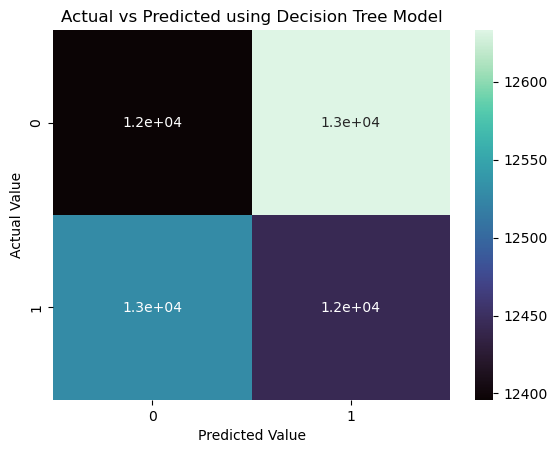

In [251]:
cm=confusion_matrix(y_test,y_pred)
plt.title('Actual vs Predicted using Decision Tree Model')
sns.heatmap(cm,annot = True,cmap='mako')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

###### Step 5.3.3: Checking Model Score

In [252]:
dt_score=accuracy_score(y_test,y_pred)
dt_score

0.49678

### Step 5.4:  Ensemble ML Model

###### Step 5.4.1: Bagging Technique Model>> Random Forest ML Model

###### Step 5.4.2: Import Random Forest Model

In [253]:
model_rf= RandomForestClassifier(n_estimators=200)#parameter change Default Tree 100 to 200
model_rf.fit(X_train,y_train)#Learning

RandomForestClassifier(n_estimators=200)

###### Step 5.4.3: Model Prediction

In [254]:
y_pred=model_rf.predict(X_test)

In [255]:
print('Accuracy Score:',accuracy_score(y_test,y_pred))
print('Precision Score:',precision_score(y_test,y_pred))
print('Recall Score:',recall_score(y_test,y_pred))
print('F1 Score:',f1_score(y_test,y_pred))

Accuracy Score: 0.49872
Precision Score: 0.4980411980285606
Recall Score: 0.47346922430018823
F1 Score: 0.48544446725518375


In [256]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.50      0.52      0.51     25029
           1       0.50      0.47      0.49     24971

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000



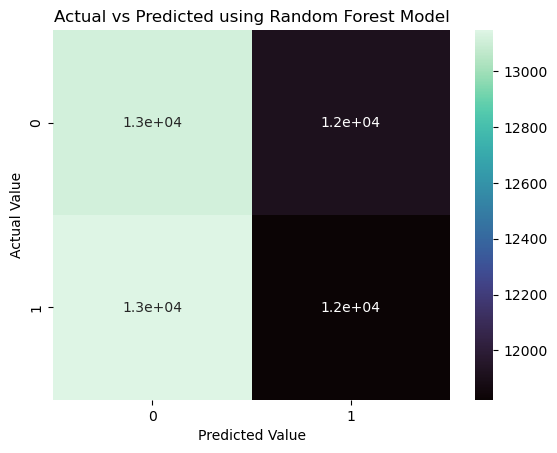

In [257]:
cm=confusion_matrix(y_test,y_pred)
plt.title('Actual vs Predicted using Random Forest Model')
sns.heatmap(cm,annot = True,cmap='mako')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

###### Step 5.4.4 Checking Model Score

In [260]:
rf_score=accuracy_score(y_test,y_pred)
rf_score

0.49872

### Step 5.5 Ensemble Boosting Technique: Adaboost, Gradientboost, XGboost
- Adaboost: Adaptive Boosting
- Gradientboost:GBM
- LBM:Gradientboost: LGBM(Light Gradient Bossting Model)
- XGBoost:Extreme Gradient Boosting:
- Catboost: Categorical : Texual Data

###### Step 5.5.1: Import XGboost ML Algorithm

In [71]:
#pip install xgboost

In [261]:
import xgboost
print('done')

done


In [262]:
model_xgb=XGBClassifier()#Hyperparameter : Models Fine Tune objective='binary:Logistic' , random_state=42, Learning_rate=0.001
model_xgb.fit(X_train,y_train)#NONE:Hyper Parameter: /Model Fine Tune

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

###### Step 5.5.2: Model Prediction

In [263]:
y_pred=model_xgb.predict(X_test)

###### Step 5.5.3: Checking Model Score

In [264]:
xgb_score=accuracy_score(y_test,y_pred)
xgb_score

0.49764

### Step 5.6: KNN: Regression and Classification

###### Step 5.6.1: Import KNN

In [265]:
model_knn= KNeighborsClassifier(n_neighbors=14)
model_knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=14)

###### Step 5.6.2: Model Prediction

In [266]:
y_pred=model_knn.predict(X_test)

In [267]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.50      0.60      0.55     25029
           1       0.50      0.39      0.44     24971

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.49     50000
weighted avg       0.50      0.50      0.49     50000



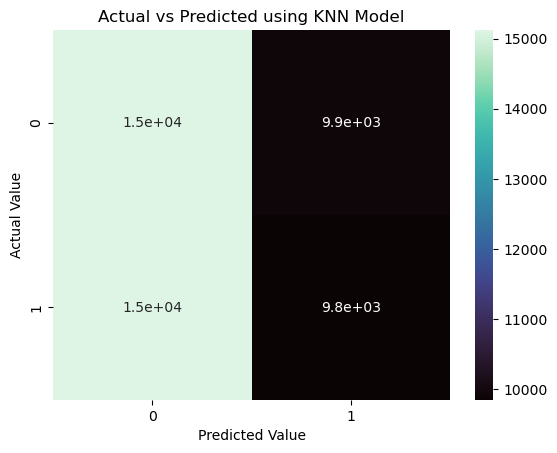

In [268]:
cm=confusion_matrix(y_test,y_pred)
plt.title('Actual vs Predicted using KNN Model')
sns.heatmap(cm,annot = True,cmap='mako')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

###### Step 5.6.3: Checking Model Score

In [269]:
knn_score=accuracy_score(y_test,y_pred)
knn_score

0.49926

# Step 7: Comparison of Machine Learning Model Performance

In [272]:
all_model_score=[lr_score,nv_score,dt_score,rf_score,xgb_score,knn_score]

model_name = ['Logistic','Naive','Decision Tree','Random Forest','XGB','Knn']

print('Done')

Done


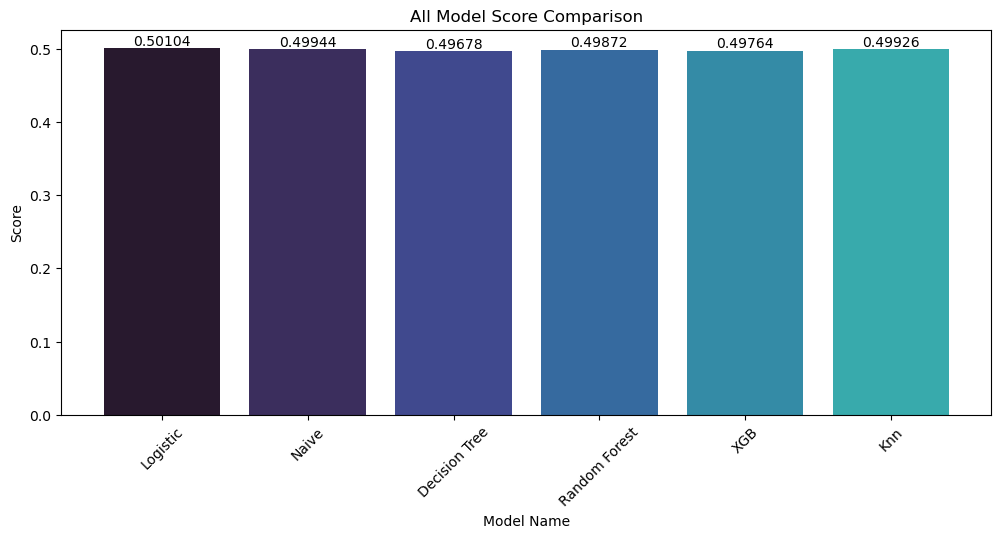

In [273]:
plt.figure(figsize=(12,5))
plt.title('All Model Score Comparison')
ax = plt.bar(x = model_name, height= all_model_score,color = sns.color_palette('mako',8))
plt.bar_label(ax)
plt.xlabel('Model Name')
plt.ylabel('Score')
plt.xticks(rotation = 45)
plt.show()

# Step 8:  DL Model Building

###### Step 8.1: Define a Function to Plot Training History

In [130]:
def plot_history(history, main_title):
    plt.figure(figsize=(12, 5))

    plt.suptitle(main_title, fontsize=20, fontweight='bold')

    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.92]) 
    plt.show()



###### Step 8.2: Setup Early Stopping

In [131]:
early_stopping = EarlyStopping(
    monitor='val_loss',  
    patience=10,           
    restore_best_weights=True  
)

### Step 8.3: Neural Network Model

###### Step 8.3.1 Build the Neural Network Model

In [132]:
# NN Model 
simple_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), 
    Dense(32, activation='relu'),  
    Dense(1, activation='sigmoid')  
])

simple_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
simple_nn.summary()





C:\Users\pankh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                     │ (None, 64)                  │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

###### Step 8.3.2: Train the Model

In [133]:
history = simple_nn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5002 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6947
Epoch 2/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 956us/step - accuracy: 0.5008 - loss: 0.6932 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 3/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 954us/step - accuracy: 0.5015 - loss: 0.6932 - val_accuracy: 0.4989 - val_loss: 0.6932
Epoch 4/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 974us/step - accuracy: 0.5020 - loss: 0.6931 - val_accuracy: 0.5005 - val_loss: 0.6932
Epoch 5/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 920us/step - accuracy: 0.5033 - loss: 0.6931 - val_accuracy: 0.4982 - val_loss: 0.6936
Epoch 6/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 947us/step - accuracy: 0.5028 - loss: 0.6930 - val_accuracy: 0.4992 - val_loss: 0.6933
Epoch 7/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 947us/step - accuracy: 0.5055 - loss: 0.6929 - val_accuracy: 0.4985 - val_loss: 0.6936
Epoch 8/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.5052 - los

###### Step 8.3.3: Evaluate on Test Data

In [134]:
test_loss, test_accuracy = simple_nn.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.5005


###### Step 8.3.4: Prediction

In [135]:
y_pred = simple_nn.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 482us/step


###### Step 8.3.5: Calculate Accuracy

In [136]:
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5005


###### Step 8.3.6: Plot Training History

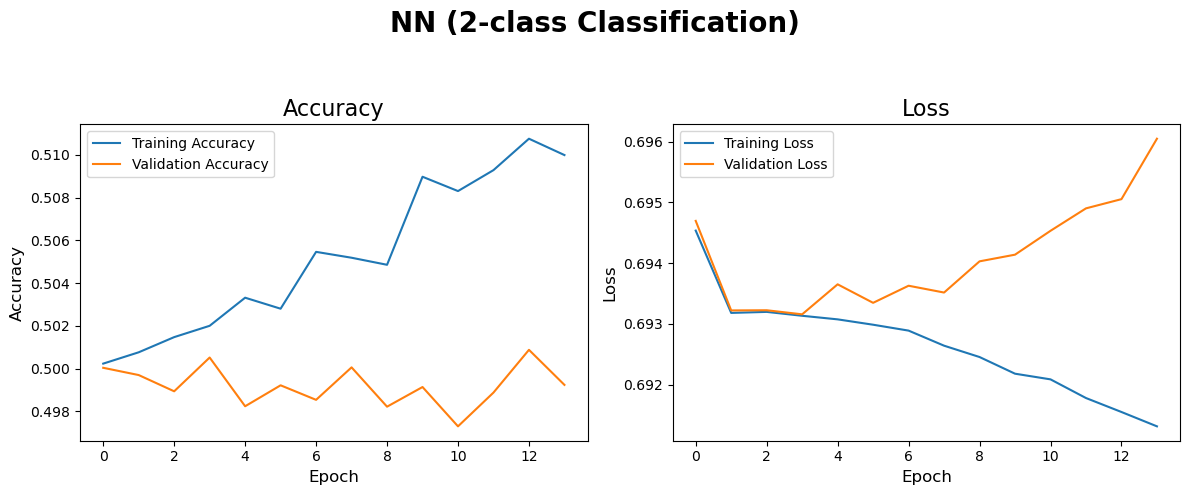

In [137]:
plot_history(history.history, "NN (2-class Classification)")

###### Step 8.3.7: Confusion Matrix

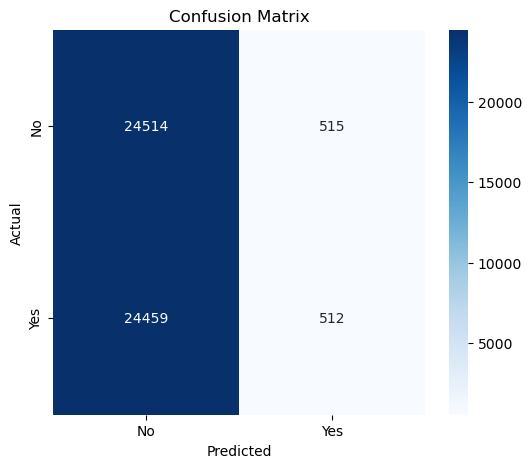

In [138]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No', 'Yes'],  
            yticklabels=['No', 'Yes'])  

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Step 8.4: DNN Model

###### Step 8.4.1: Build the DNN Model

In [146]:
# DNN Model 
dnn_model = Sequential([
   Input(shape=(X_train.shape[1],)), Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                     │ (None, 128)                 │           2,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 384 (1.50 KB)

###### Step 8.4.2: Define Early Stopping

In [139]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

###### Step 8.4.3: Train the Model

In [147]:
history = dnn_model.fit(
    X_train, y_train,  
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),  
    callbacks=[early_stopping]
)

Epoch 1/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.5008 - loss: 0.6992 - val_accuracy: 0.5029 - val_loss: 0.6933
Epoch 2/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.5004 - loss: 0.6935 - val_accuracy: 0.5006 - val_loss: 0.6932
Epoch 3/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.4995 - loss: 0.6933 - val_accuracy: 0.5001 - val_loss: 0.6932
Epoch 4/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.5003 - loss: 0.6933 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 5/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.4986 - loss: 0.6932 - val_accuracy: 0.5014 - val_loss: 0.6932
Epoch 6/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.5009 - loss: 0.6932 - val_accuracy: 0.5006 - val_loss: 0.6932
Epoch 7/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.4985 - loss: 0.6932 - val_accuracy: 0.5012 - val_loss: 0.6931
Epoch 8/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.4990 - loss: 0.6932

###### Step 8.4.4: Prediction

In [148]:
y_pred = dnn_model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step 


###### Step 8.4.5: Calculate Accuracy

In [149]:
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5023


###### Step 8.4.6: Plot Training History

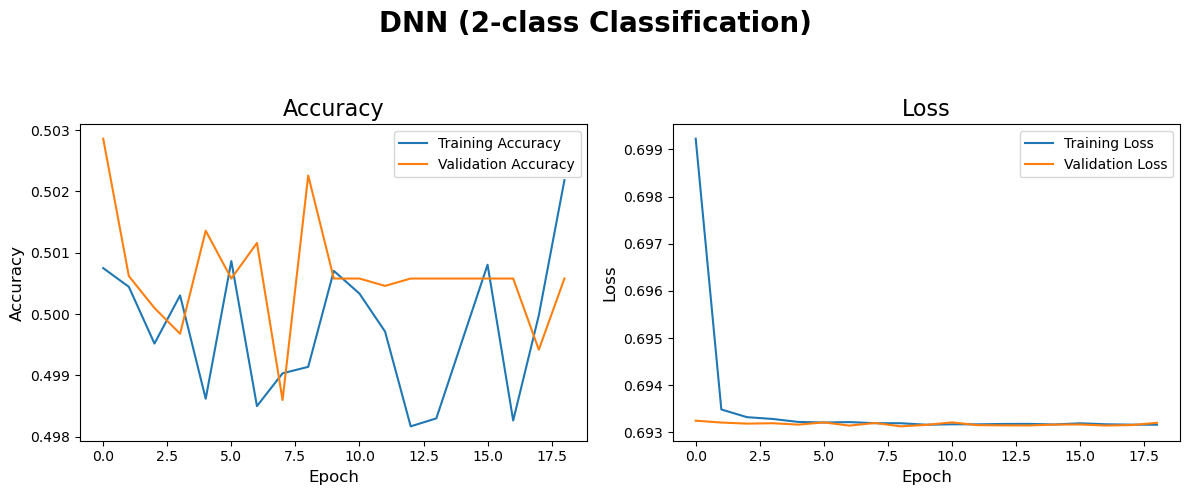

In [150]:
plot_history(history.history, "DNN (2-class Classification)")


###### Step 8.4.7: Confusion Matrix

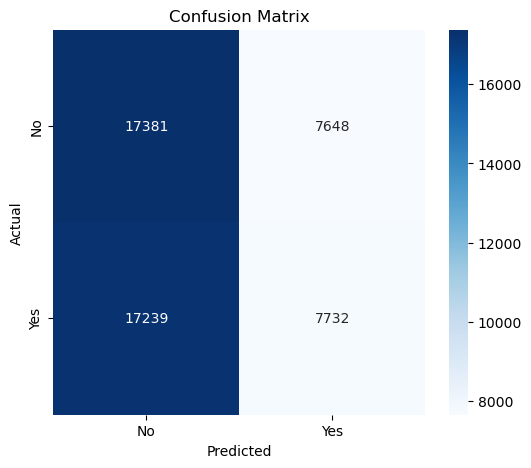

In [151]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No', 'Yes'],  
            yticklabels=['No', 'Yes'])  

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Step 8.5: ANN Model

In [82]:
#pip install tensorflow

In [81]:
#pip install keras

###### Step 8.5.1: Build the ANN Model

In [157]:
ann_model = Sequential([
    Input(shape=(X_train.shape[1],)), Dense(128, activation='relu'),
    Dropout(0.3),  
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                     │ (None, 128)                 │           2,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_57 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_58 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

###### Step 8.5.2: Define Early Stopping

In [158]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

###### Step 8.5.3: Train the Model

In [159]:
history = ann_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/50
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - accuracy: 0.4995 - loss: 0.6943 - val_accuracy: 0.4993 - val_loss: 0.6932
Epoch 2/50
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 12s 994us/step - accuracy: 0.4990 - loss: 0.6933 - val_accuracy: 0.4995 - val_loss: 0.6934
Epoch 3/50
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - accuracy: 0.4990 - loss: 0.6932 - val_accuracy: 0.5006 - val_loss: 0.6931
Epoch 4/50
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step - accuracy: 0.4995 - loss: 0.6932 - val_accuracy: 0.4994 - val_loss: 0.6931
Epoch 5/50
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - accuracy: 0.4998 - loss: 0.6932 - val_accuracy: 0.4995 - val_loss: 0.6932
Epoch 6/50
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.4986 - loss: 0.6933 - val_accuracy: 0.4993 - val_loss: 0.6932
Epoch 7/50
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.4986 - loss: 0.6932 - val_accuracy: 0.4995 - val_loss: 0.6932
Epoch 8/50
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy

###### Step 8.5.4: Evaluate the Model

In [160]:
test_loss, test_accuracy = ann_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.5006


###### Step 8.5.5: Prediction

In [161]:
y_pred = ann_model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 411us/step


###### Step 8.5.6: Calculate Accuracy

In [162]:
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5006


###### Step 8.5.7: Plot Training History

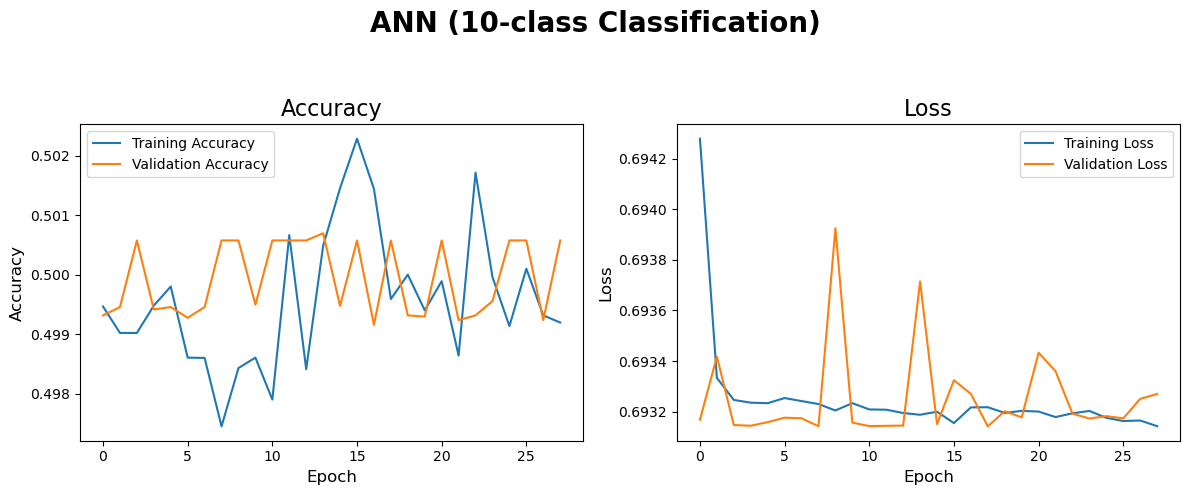

In [163]:
plot_history(history.history, "ANN (10-class Classification)")

###### Step 8.5.8: Confusion Matrix

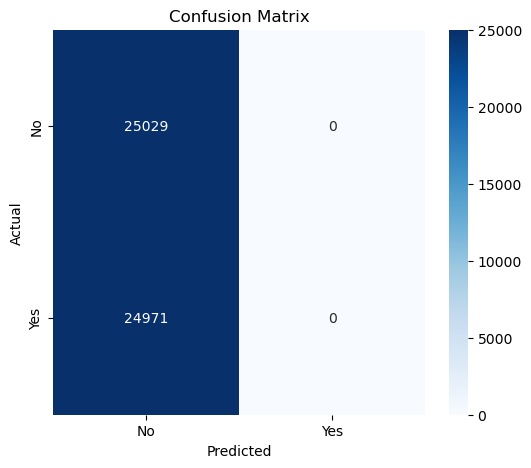

In [164]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No', 'Yes'],  
            yticklabels=['No', 'Yes'])  

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Step 8.6: MLP Model

###### Step 8.6.1: Build the MLP Model

In [169]:
# MLP Model
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp_model.summary()

C:\Users\pankh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                     │ (None, 128)                 │           2,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_60 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_61 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

###### Step 8.6.2: Define Early Stopping

In [170]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

###### Step 8.6.3: Train the Model

In [172]:
history = mlp_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.4993 - loss: 0.6946 - val_accuracy: 0.5005 - val_loss: 0.6932
Epoch 2/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.4995 - loss: 0.6933 - val_accuracy: 0.5002 - val_loss: 0.6932
Epoch 3/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.4988 - loss: 0.6932 - val_accuracy: 0.5006 - val_loss: 0.6933
Epoch 4/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5002 - loss: 0.6932 - val_accuracy: 0.4994 - val_loss: 0.6932
Epoch 5/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.5018 - loss: 0.6932 - val_accuracy: 0.4995 - val_loss: 0.6932
Epoch 6/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.4991 - loss: 0.6932 - val_accuracy: 0.5006 - val_loss: 0.6932
Epoch 7/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.5005 - loss: 0.6932 - val_accuracy: 0.5006 - val_loss: 0.6932
Epoch 8/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.5009 - loss: 0.6932 -

###### Step 8.6.4: Evaluate the Model

In [173]:
test_loss, test_accuracy = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.5006


###### Step 8.6.5: Predictions

In [174]:
y_pred = mlp_model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 591us/step 


###### Step 8.6.6: Calculate Accuracy

In [175]:
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5006


###### Step 8.6.7: Plot History Training

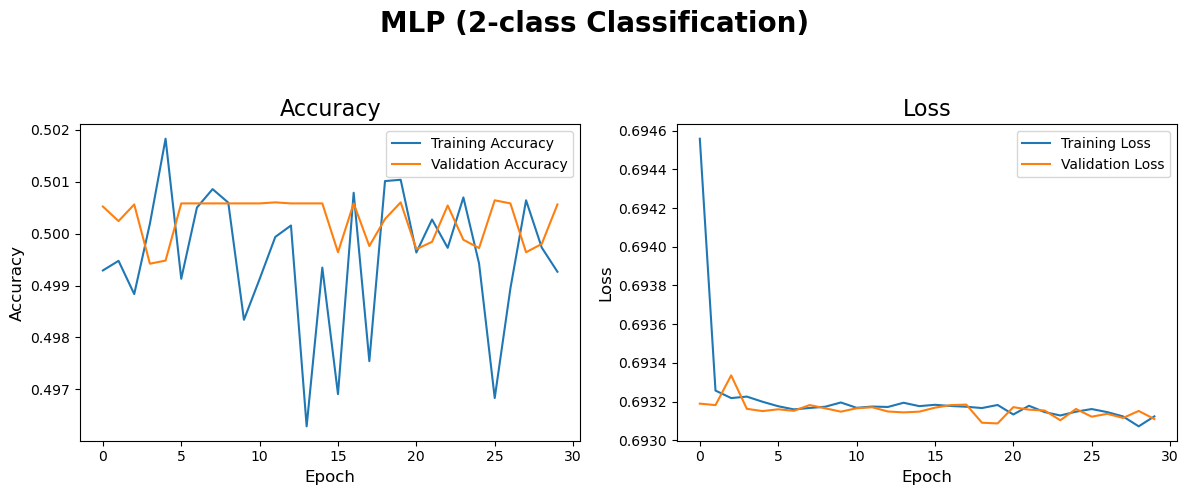

In [176]:
plot_history(history.history, "MLP (2-class Classification)")


###### Step 8.6.8: Confusion Matrix

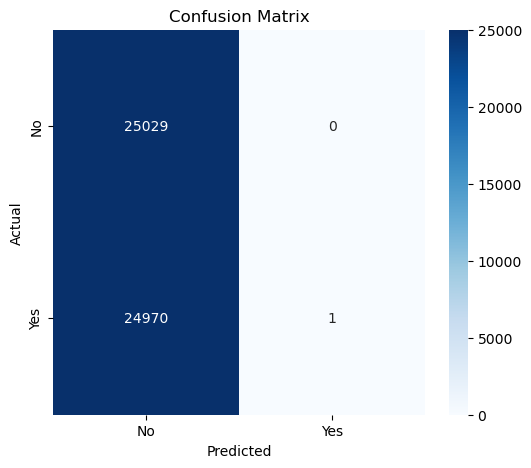

In [177]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No', 'Yes'],  
            yticklabels=['No', 'Yes'])  

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Step 8.7: CNN Model

###### Step 8.7.1: Reshape Input Data for Conv1D

In [178]:
X_train_np = X_train.values
X_test_np = X_test.values

X_train_reshaped = X_train_np.reshape((X_train_np.shape[0], X_train_np.shape[1], 1))  
X_test_reshaped = X_test_np.reshape((X_test_np.shape[0], X_test_np.shape[1], 1))


###### Step 8.7.2: Build the CNN ModeL

In [179]:
cnn_model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  
])

cnn_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

cnn_model.summary()

C:\Users\pankh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)                    │ (None, 19, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 9, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 288)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 64)                  │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

###### Step 8.7.3: Define Early Stopping

In [180]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

###### Step 8.7.4: Train the Model

In [181]:
history = cnn_model.fit(
    X_train_reshaped, y_train,  
    epochs=50,
    batch_size=32,
    validation_data=(X_test_reshaped, y_test),  
    callbacks=[early_stopping]
)

Epoch 1/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.4999 - loss: 0.6942 - val_accuracy: 0.4993 - val_loss: 0.6932
Epoch 2/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.4996 - loss: 0.6932 - val_accuracy: 0.5005 - val_loss: 0.6933
Epoch 3/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.5014 - loss: 0.6932 - val_accuracy: 0.4992 - val_loss: 0.6932
Epoch 4/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.5023 - loss: 0.6931 - val_accuracy: 0.5014 - val_loss: 0.6932
Epoch 5/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.5017 - loss: 0.6932 - val_accuracy: 0.5001 - val_loss: 0.6932
Epoch 6/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.5008 - loss: 0.6931 - val_accuracy: 0.5008 - val_loss: 0.6932
Epoch 7/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.5030 - loss: 0.6931 - val_accuracy: 0.4965 - val_loss: 0.6933
Epoch 8/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.5040 - loss: 0

###### Step 8.7.5: Evaluate the Model

In [182]:
test_loss, test_accuracy = cnn_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.4993


###### Step 8.7.6: Predictions

In [183]:
y_pred = cnn_model.predict(X_test_reshaped)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step


###### Step 8.7.7: Calculate Accuracy

In [184]:
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.4993


###### Step 8.7.8: Plot Training History

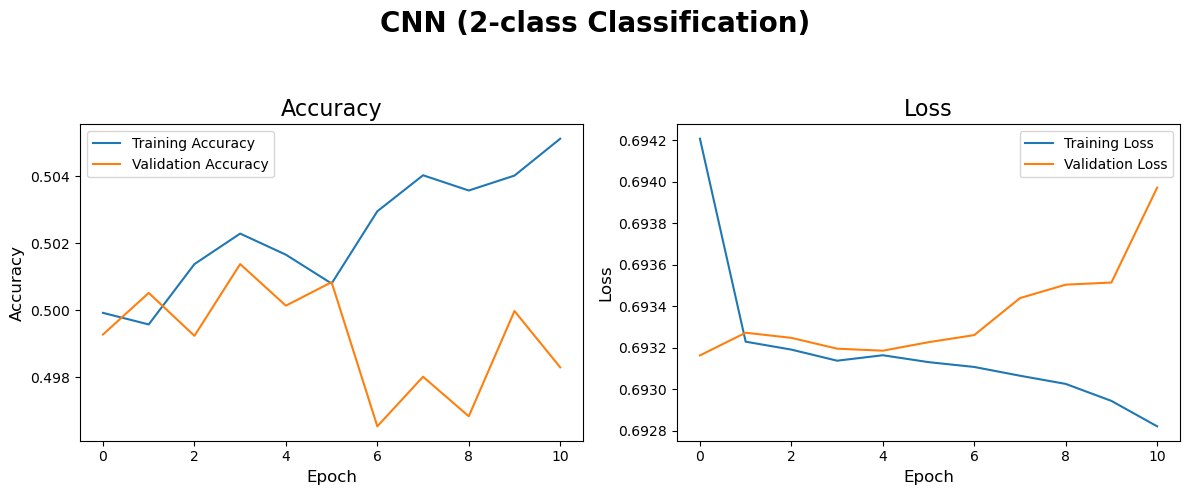

In [185]:
plot_history(history.history, "CNN (2-class Classification)")

###### Step 8.7.9: Confusion Matrix

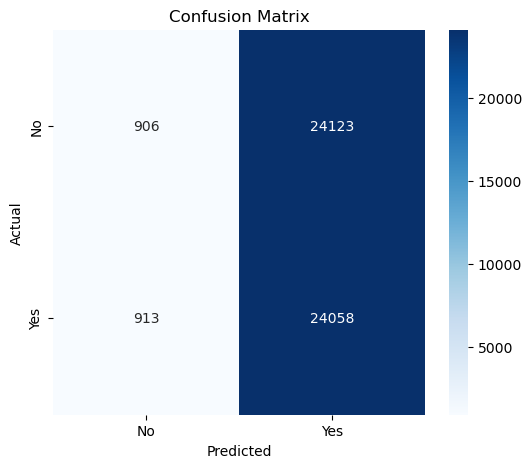

In [186]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No', 'Yes'],  
            yticklabels=['No', 'Yes'])  

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Step 9: Comparison of Deep Learning Model Performance

In [100]:
def evaluate_model_on_test(model, X_test, y_test):
    if len(X_test.shape) == 2:  
        X_test_input = X_test
    else: 
        X_test_input = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    y_pred_prob = model.predict(X_test_input, verbose=0)

    y_pred = np.argmax(y_pred_prob, axis=1)  

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    return accuracy, precision, recall, f1

results_deep = []
models_dict = {
    "Simple NN": simple_nn,
    "DNN" : dnn_model,
    "ANN" : ann_model,
    "MLP": mlp_model,
    "CNN": cnn_model,
}

for model_name, model in models_dict.items():
    acc, precision, recall, f1 = evaluate_model_on_test(model, X_test, y_test)
    
    results_deep.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })
results_df2 = pd.DataFrame(results_deep)
results_df2

,Model,Accuracy,Precision,Recall,F1-Score
0,Simple NN,0.50058,0.25058,0.50058,0.333978
1,DNN,0.50058,0.25058,0.50058,0.333978
2,ANN,0.50058,0.25058,0.50058,0.333978
3,MLP,0.50058,0.25058,0.50058,0.333978
4,CNN,0.50058,0.25058,0.50058,0.333978



Best Model (Deep Learning):
Model        Simple NN
Accuracy       0.50058
Precision      0.25058
Recall         0.50058
F1-Score      0.333978
Name: 0, dtype: object


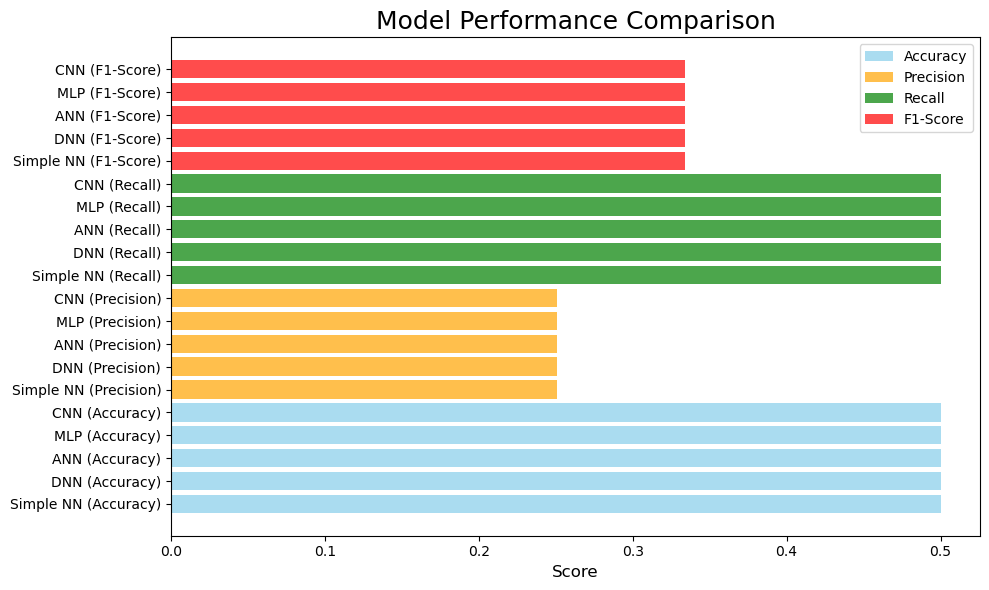


Optimal Model based on Accuracy: Simple NN with Accuracy = 0.5006


In [101]:
best_model2 = results_df2.loc[results_df2['Accuracy'].idxmax()]
print("\nBest Model (Deep Learning):")
print(best_model2)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors = ["skyblue", "orange", "green", "red"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    ax.barh(results_df2["Model"] + f" ({metric})", results_df2[metric], color=colors[i], alpha=0.7, label=metric)

ax.set_xlabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison", fontsize=18)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nOptimal Model based on Accuracy: {best_model2['Model']} with Accuracy = {best_model2['Accuracy']:.4f}")


### Step 10: Model Save

In [102]:
import pickle
with open('brain_tumor_pred.pkl','wb') as f:
    pickle.dump(model_lr,f)
print('done')

done


In [103]:
import os
cr=os.getcwd()
print(cr)

C:\Users\pankh\brain tumor project


In [114]:

model.save('brain_tumor_pred_model.keras')


In [122]:
# Load your dataset
df = pd.read_csv('Brain_Tumor_Prediction_Dataset.csv')

# Drop the target column
X = df.drop('Brain_Tumor_Present', axis=1)

# Replace 'Blood_Pressure' with 'High_BP' and 'Low_BP' if you've already split it
if 'Blood_Pressure' in X.columns:
    def split_bp(bp):
        try:
            high, low = bp.split('/')
            return pd.Series({'High_BP': float(high), 'Low_BP': float(low)})
        except:
            return pd.Series({'High_BP': 120, 'Low_BP': 80})  # Default values

    bp_split = X['Blood_Pressure'].apply(split_bp)
    X = X.drop('Blood_Pressure', axis=1)
    X = pd.concat([X, bp_split], axis=1)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# ✅ Fit the scaler
scaler = StandardScaler()
scaler.fit(X)

# ✅ Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# ✅ Save the encoders
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Scaler and encoders saved successfully.")


Scaler and encoders saved successfully.
